In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("diabetes_prediction_dataset.csv")
print(df)
print('-'*100)

       gender   age  hypertension  heart_disease smoking_history    bmi  \
0      Female  80.0             0              1           never  25.19   
1      Female  54.0             0              0         No Info  27.32   
2        Male  28.0             0              0           never  27.32   
3      Female  36.0             0              0         current  23.45   
4        Male  76.0             1              1         current  20.14   
...       ...   ...           ...            ...             ...    ...   
99995  Female  80.0             0              0         No Info  27.32   
99996  Female   2.0             0              0         No Info  17.37   
99997    Male  66.0             0              0          former  27.83   
99998  Female  24.0             0              0           never  35.42   
99999  Female  57.0             0              0         current  22.43   

       HbA1c_level  blood_glucose_level  diabetes  
0              6.6                  140        

In [3]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [4]:
print("\nBASIC INFORMATION:\n >> Info")
print('-'*30)
df.info()
print('_'*100)


BASIC INFORMATION:
 >> Info
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
____________________________________________________________________________________________________


In [5]:
print("\n BASIC INFORMATION:\n >> Head")
print('-'*30)
df.head().T


 BASIC INFORMATION:
 >> Head
------------------------------


,0,1,2,3,4
gender,Female,Female,Male,Female,Male
age,80.0,54.0,28.0,36.0,76.0
hypertension,0,0,0,0,1
heart_disease,1,0,0,0,1
smoking_history,never,No Info,never,current,current
bmi,25.19,27.32,27.32,23.45,20.14
HbA1c_level,6.6,6.6,5.7,5.0,4.8
blood_glucose_level,140,80,158,155,155
diabetes,0,0,0,0,0


In [6]:
print("\n PERFORM DESCRIBE:\n >> Describe()")
print('-'*30)
df.describe().T



 PERFORM DESCRIBE:
 >> Describe()
------------------------------


,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.074850,0.263150,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039420,0.194593,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.085000,0.278883,0.00,0.00,0.00,0.00,1.00


In [7]:
print("\nHANDLE MISSING VALUES:\n >> Missing Values ")
df.isnull()


HANDLE MISSING VALUES:
 >> Missing Values 


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
99995,False,False,False,False,False,False,False,False,False
99996,False,False,False,False,False,False,False,False,False
99997,False,False,False,False,False,False,False,False,False
99998,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().T

,0,1,2,3,4,5,6,7,8,9,...,99990,99991,99992,99993,99994,99995,99996,99997,99998,99999
gender,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
age,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
hypertension,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
heart_disease,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
smoking_history,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
bmi,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
HbA1c_level,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
blood_glucose_level,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
diabetes,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [10]:
df.isnull().sum().sort_values(ascending=False)

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [11]:
df.isnull().sum().sort_values(ascending=True)

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [12]:
print('>> Fillna Function')
print('_'*30)

>> Fillna Function
______________________________


In [13]:
df['age'].fillna(df['age'].mean(),inplace=True)
df['age'].fillna(df['age'].mean(),inplace=False)

C:\Users\aj381\AppData\Local\Temp\ipykernel_16196\2549541004.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(),inplace=True)


0        80.0
1        54.0
2        28.0
3        36.0
4        76.0
         ... 
99995    80.0
99996     2.0
99997    66.0
99998    24.0
99999    57.0
Name: age, Length: 100000, dtype: float64

In [14]:
df.fillna(df['age'].mean(),inplace=False)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [15]:
df['bmi'].fillna(df['bmi'].mode()[0], inplace=False)

0        25.19
1        27.32
2        27.32
3        23.45
4        20.14
         ...  
99995    27.32
99996    17.37
99997    27.83
99998    35.42
99999    22.43
Name: bmi, Length: 100000, dtype: float64

In [16]:
print("\n  >> Drop Function")
print('_'*30)


  >> Drop Function
______________________________


In [17]:

df.drop(columns=['smoking_history'])

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,25.19,6.6,140,0
1,Female,54.0,0,0,27.32,6.6,80,0
2,Male,28.0,0,0,27.32,5.7,158,0
3,Female,36.0,0,0,23.45,5.0,155,0
4,Male,76.0,1,1,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,27.32,6.2,90,0
99996,Female,2.0,0,0,17.37,6.5,100,0
99997,Male,66.0,0,0,27.83,5.7,155,0
99998,Female,24.0,0,0,35.42,4.0,100,0


In [18]:
df.drop(columns=['age'],inplace=True)

In [19]:
df.drop(columns=['gender'],inplace=False)

,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,1,never,25.19,6.6,140,0
1,0,0,No Info,27.32,6.6,80,0
2,0,0,never,27.32,5.7,158,0
3,0,0,current,23.45,5.0,155,0
4,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...
99995,0,0,No Info,27.32,6.2,90,0
99996,0,0,No Info,17.37,6.5,100,0
99997,0,0,former,27.83,5.7,155,0
99998,0,0,never,35.42,4.0,100,0


In [20]:
print("\n  >> Dropna Function")
print('_'*30)




  >> Dropna Function
______________________________


In [21]:
df.dropna(subset=['blood_glucose_level'])

,gender,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,0,1,never,25.19,6.6,140,0
1,Female,0,0,No Info,27.32,6.6,80,0
2,Male,0,0,never,27.32,5.7,158,0
3,Female,0,0,current,23.45,5.0,155,0
4,Male,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...
99995,Female,0,0,No Info,27.32,6.2,90,0
99996,Female,0,0,No Info,17.37,6.5,100,0
99997,Male,0,0,former,27.83,5.7,155,0
99998,Female,0,0,never,35.42,4.0,100,0


In [22]:
df.dropna(subset=['blood_glucose_level'],inplace=False)

,gender,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,0,1,never,25.19,6.6,140,0
1,Female,0,0,No Info,27.32,6.6,80,0
2,Male,0,0,never,27.32,5.7,158,0
3,Female,0,0,current,23.45,5.0,155,0
4,Male,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...
99995,Female,0,0,No Info,27.32,6.2,90,0
99996,Female,0,0,No Info,17.37,6.5,100,0
99997,Male,0,0,former,27.83,5.7,155,0
99998,Female,0,0,never,35.42,4.0,100,0


In [23]:
print("\n >> REMOVE UNNECESSARY COLUMNS")
print('_'*30)


 >> REMOVE UNNECESSARY COLUMNS
______________________________


In [24]:


df.drop(columns=['age','blood_glucose_level',],inplace=False,axis=1,errors='ignore')

,gender,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,diabetes
0,Female,0,1,never,25.19,6.6,0
1,Female,0,0,No Info,27.32,6.6,0
2,Male,0,0,never,27.32,5.7,0
3,Female,0,0,current,23.45,5.0,0
4,Male,1,1,current,20.14,4.8,0
...,...,...,...,...,...,...,...
99995,Female,0,0,No Info,27.32,6.2,0
99996,Female,0,0,No Info,17.37,6.5,0
99997,Male,0,0,former,27.83,5.7,0
99998,Female,0,0,never,35.42,4.0,0


In [25]:

print("\n        2) DATA ANALYSIS \n@) identitfy outliers \n@) Visualize outliers(boxplot) \n@) Remove Outliers \n@) Plot:\n    >Hitogram \n    >Correlation Heatmap")


        2) DATA ANALYSIS 
@) identitfy outliers 
@) Visualize outliers(boxplot) 
@) Remove Outliers 
@) Plot:
    >Hitogram 
    >Correlation Heatmap


In [26]:
print("\n  >> Idetitfy Outliers")
print('_'*30)


  >> Idetitfy Outliers
______________________________


In [27]:
numeric_data = df.select_dtypes(include=[np.number])

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

print(Q1)
print(Q3)
print(IQR)

hypertension             0.00
heart_disease            0.00
bmi                     23.63
HbA1c_level              4.80
blood_glucose_level    100.00
diabetes                 0.00
Name: 0.25, dtype: float64
hypertension             0.00
heart_disease            0.00
bmi                     29.58
HbA1c_level              6.20
blood_glucose_level    159.00
diabetes                 0.00
Name: 0.75, dtype: float64
hypertension            0.00
heart_disease           0.00
bmi                     5.95
HbA1c_level             1.40
blood_glucose_level    59.00
diabetes                0.00
dtype: float64


In [28]:
print("\n >> Visualize outliers(boxplot): ")
print('_'*30)


 >> Visualize outliers(boxplot): 
______________________________


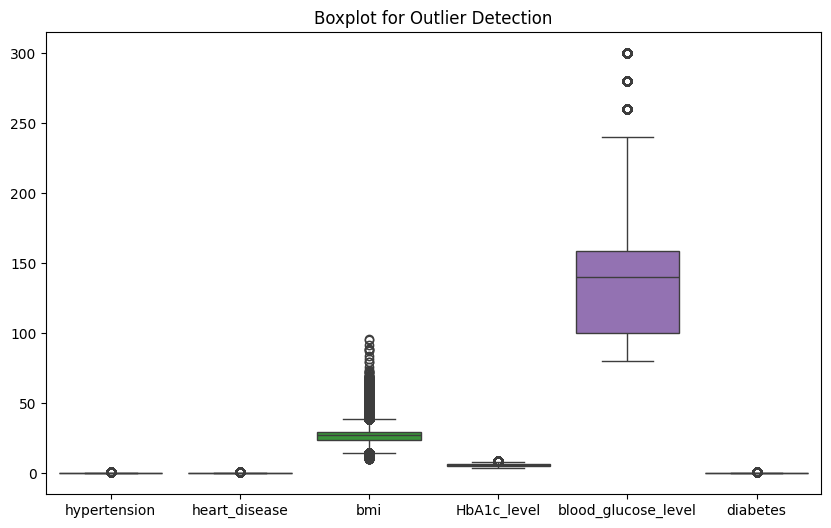

In [29]:
#boxplot

plt.figure(figsize=(10,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.title("Boxplot for Outlier Detection")
plt.show()

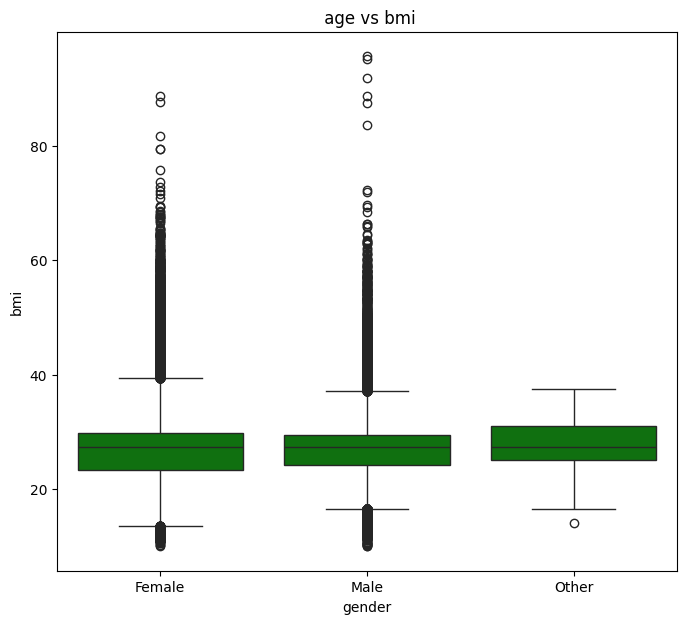

In [30]:
#boxplot Plot (Relation Between 2 Numerical Columns)

plt.figure(figsize=(8,7))
sns.boxplot(x='gender', y='bmi', data=df,color="green")
plt.title(" age vs bmi")
plt.show()

In [31]:
print("\n >> Remove Outliers:")
print('_'*30)


 >> Remove Outliers:
______________________________


In [32]:
# Remove outliers
df_clean = df[~((numeric_data < (Q1 - 1.5 * IQR)) | 
                          (numeric_data > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Original Shape:", df.shape)
print("After Removing Outliers:", df_clean.shape)


Original Shape: (100000, 8)
After Removing Outliers: (79025, 8)


In [33]:
print("\n >> plot")
print('_'*10)


 >> plot
__________


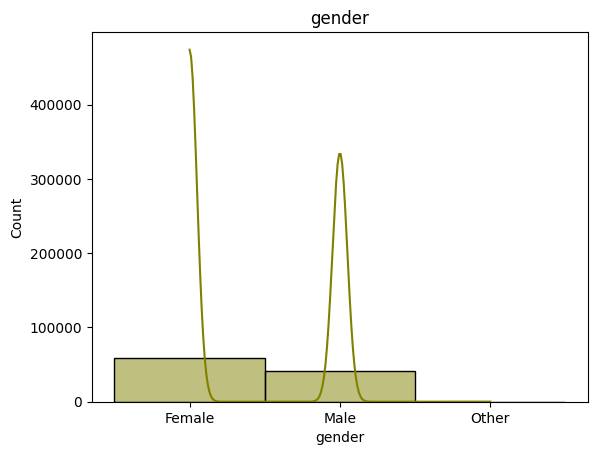

In [34]:
#histogram 
sns.histplot(df['gender'], kde=True,color="olive")
plt.title("gender")
plt.show()

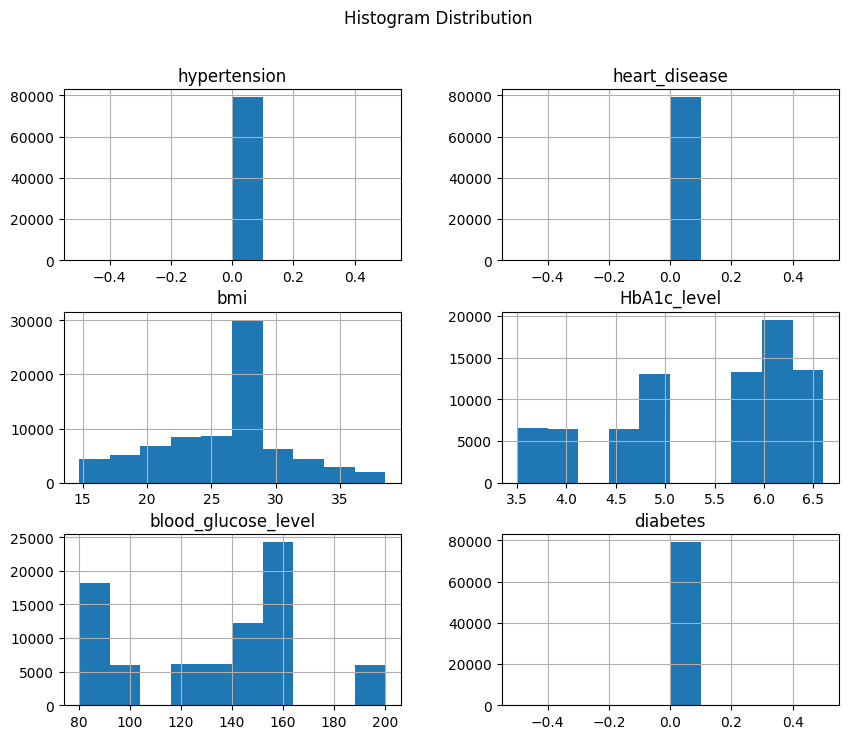

In [35]:
#histogram
df_clean.hist(figsize=(10,8))
plt.suptitle("Histogram Distribution")
plt.show()

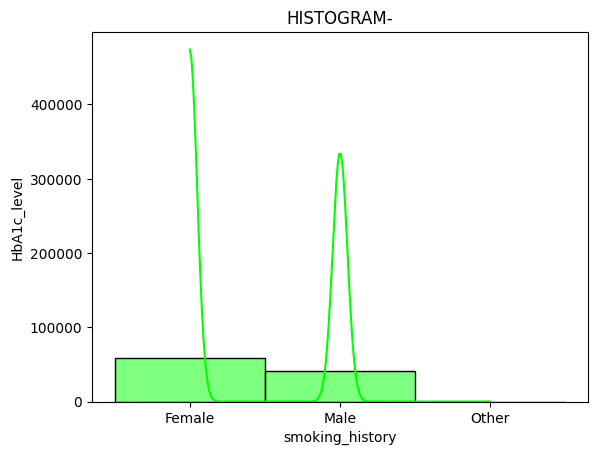

In [36]:
#histogram \\ 2 variable
sns.histplot(df['gender'], kde=True, bins=30,color="lime")
plt.title("HISTOGRAM-")
plt.xlabel("smoking_history")
plt.ylabel("HbA1c_level")
plt.show()

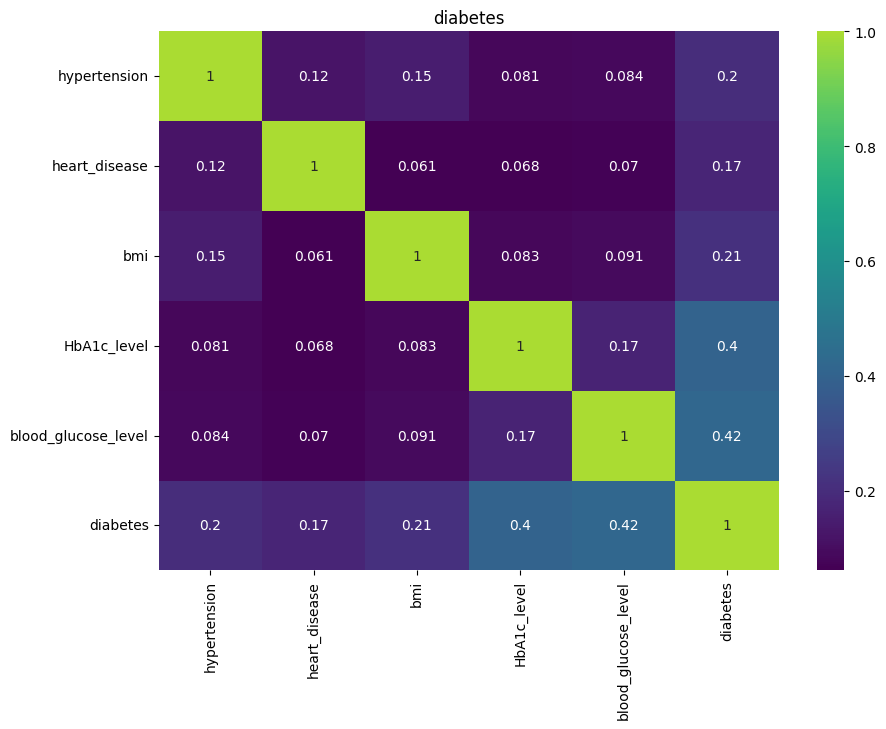

In [37]:
#Correlation Heatmap


plt.figure(figsize=(10,7))
plt.title("diabetes")
sns.heatmap(df.corr(numeric_only=True), annot=True,cmap='viridis',center=0.6) #cmap=viridis,plasma,inferno,magma,coolwarm,RdBu...etc
plt.show()

In [38]:
print("\n        3) Model Building  \n@) Split Dataset \n@) Train The Model \n@) Make Predictions on test \n@) Predict usingnew\Custominput ")


        3) Model Building  
@) Split Dataset 
@) Train The Model 
@) Make Predictions on test 
@) Predict usingnew\Custominput 


<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\aj381\AppData\Local\Temp\ipykernel_16196\3842742879.py:1: SyntaxWarning: invalid escape sequence '\C'
  print("\n        3) Model Building  \n@) Split Dataset \n@) Train The Model \n@) Make Predictions on test \n@) Predict usingnew\Custominput ")


In [39]:
print(" 4) Model Building")
print('_'*100)

 4) Model Building
____________________________________________________________________________________________________


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [60]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

print(df.head())
print(df.info())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age               

In [61]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [62]:
X = df[['age']]   # ONLY age column as requested
y = df['diabetes']

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [67]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [69]:
y_pred = model.predict(X_test)

In [70]:
y_pred_class = [1 if i >= 0.5 else 0 for i in y_pred]

In [77]:
print("\n >> linear Regression model")
print('_'*30)


 >> linear Regression model
______________________________


In [86]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("\n @)Linear Regression Results")
print('-'*30)
print("RMSE:", rmse)
print("R2 Score:", r2)


 @)Linear Regression Results
------------------------------
RMSE: 0.2700608070145241
R2 Score: 0.06624260454864073


In [73]:
accuracy = accuracy_score(y_test, y_pred_class)

print("Accuracy:", accuracy*100)

Accuracy: 91.46


In [82]:
print("\n >> logistic  Regression model")
print('_'*30)


 >> logistic  Regression model
______________________________


In [87]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

print(df.head())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [88]:
X = df[['age']]       # only age column
y = df['diabetes']   # target

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [90]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [93]:
X = df.drop('diabetes', axis=1)

In [96]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)

# Evaluation
print("\n @)Logistic Regression Results")
print('-'*30)
print("\n Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))



 @)Logistic Regression Results
------------------------------

 Accuracy: 0.9146
[[18292     0]
 [ 1708     0]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.96     18292
           1       0.00      0.00      0.00      1708

    accuracy                           0.91     20000
   macro avg       0.46      0.50      0.48     20000
weighted avg       0.84      0.91      0.87     20000



c:\Users\aj381\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aj381\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aj381\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [81]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)


print("\n @)KNN Results")
print('_'*25)
print("\n Accuracy:", accuracy_score(y_test, y_pred_knn))
print('_'*30)
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


 @)KNN Results
_________________________

 Accuracy: 0.90975
______________________________
[[18143   149]
 [ 1656    52]]
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     18292
           1       0.26      0.03      0.05      1708

    accuracy                           0.91     20000
   macro avg       0.59      0.51      0.50     20000
weighted avg       0.86      0.91      0.88     20000

